## Imports

In [18]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Simple function and numerical derivative

In [19]:
def f(x):
    return 3*x**2 - 4*x + 5

In [20]:
f(3.0)

20.0

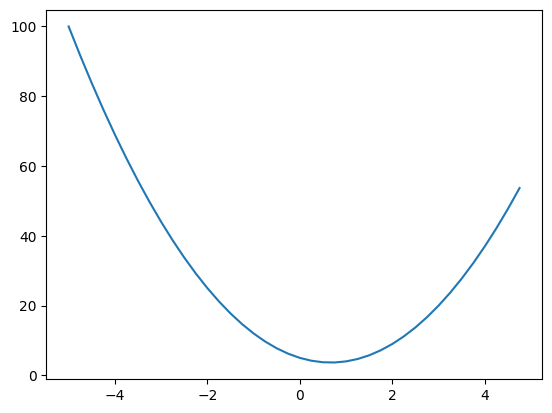

In [21]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [22]:
# https://en.wikipedia.org/wiki/Derivative
h = 0.00000001
xlist = [3.0, -3.0, 2/3]
for x in xlist:
    print((f(x + h) - f(x))/h)

14.00000009255109
-22.00000039920269
0.0


## Manual gradient example

In [23]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [24]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
#a += h
#b += h
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


## Value class

In [216]:
# Value object Datastructure
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None  # for chainrule, empty func for default
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        # Line below lets other alone if other is an intance of Value otherwise we wrap it in value and it has data attribute
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            #self.grad = 1.0 * out.grad # chainrule, but with bug "no accumulation"
            self.grad += 1.0 * out.grad # accumulate the gradients
            other.grad += 1.0 * out.grad # accumulate the gradients
            #other.grad = 1.0 * out.grad # simply copy to outgrad and othergrad
        out._backward = _backward
        return out
        
    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        # Line below lets other alone if other is an intance of Value otherwise we wrap it in value and it has data attribute
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            #self.grad = other.data * out.grad
            self.grad += other.data * out.grad # accumulate the gradients
            other.grad += self.data * out.grad # accumulate the gradients
            #other.grad = self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "Only supporting int or float powers for now!"
        out = Value(self.data**other, (self, ), f'**{other}')
        def _backward():
            #self.grad = other.data * out.grad
            # https://www.cuemath.com/derivative-formula/
            self.grad += (other * self.data ** (other - 1)) * out.grad # local derivaties * chain rule
            #other.grad = self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other): # fallback if for example 2 * a -> other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __neg__(self): # - self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)

    def tanh(self):
        # https://en.wikipedia.org/wiki/Hyperbolic_functions
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            #self.grad = (1 - t**2) * out.grad # no accumulation
            self.grad += (1 - t**2) * out.grad # accumulate the gradients
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            #self.grad = (1 - t**2) * out.grad # no accumulation
            self.grad += out.data * out.grad # as we got exp to the x from out
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

## First computation graph: L = (a*b + c) * f

In [98]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e+c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

## Graphviz visualization

In [99]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

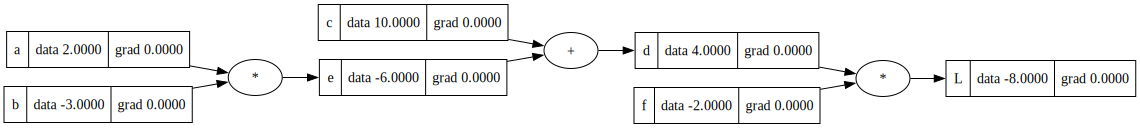

In [100]:
draw_dot(L)

## Manual backprop for L

Chain rule: work right-to-left through the graph.

```
# chain rule: dL/dc = (dL/dd) * (dd/dc)
# + nodes route gradients (dd/dc = 1, dd/de = 1)
# * nodes: dL/da = (dL/de) * (de/da) = dL/de * b
```

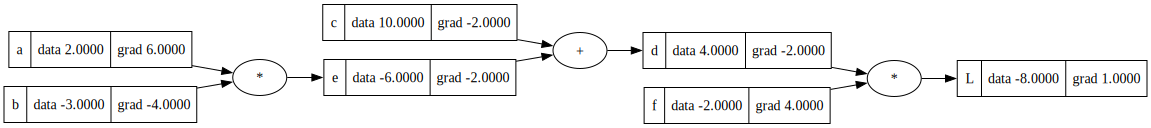

In [101]:
# Backprop right to left

# Output
L.grad = 1.0

# L = d * f  =>  dL/df = d,  dL/dd = f
f.grad = d.data        # = 4.0
d.grad = f.data        # = -2.0

# d = e + c  =>  dd/de = 1,  dd/dc = 1  =>  dL/de = dL/dd * 1,  dL/dc = dL/dd * 1
e.grad = d.grad        # = -2.0
c.grad = d.grad        # = -2.0

# e = a * b  =>  de/da = b,  de/db = a
a.grad = b.data * e.grad   # = -3.0 * -2.0 = 6.0
b.grad = a.data * e.grad   # = 2.0 * -2.0 = -4.0

draw_dot(L)

## Gradient update step

In [102]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


## Numerical gradient check

In [103]:
def lol():
    h = 0.001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    #a.data += h
    b = Value(-3.0, label='b')
    #b.data += h
    c = Value(10.0, label='c')
    #c.data += h
    e = a*b; e.label = 'e'
    #e.data += h
    d = e+c; d.label = 'd'
    #d.data += h  # we expect -2
    f = Value(-2.0, label='f')  # + h we expect 4
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol()
# Inline gradient check, numerical gradient is with small h step sizes

0.0


## tanh activation function

https://cs231n.github.io/neural-networks-1/

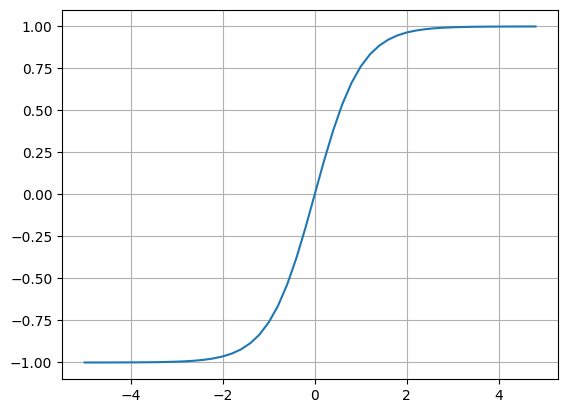

In [104]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid();

## Neuron computation graph: o = tanh(x1*w1 + x2*w2 + b)

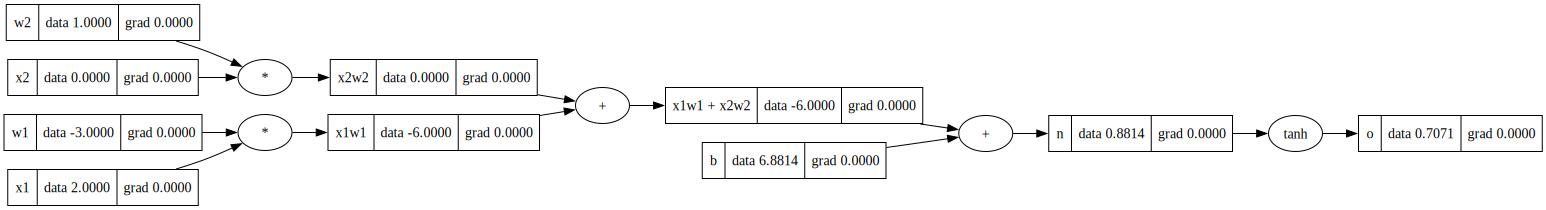

In [105]:
# https://cs231n.github.io/neural-networks-1/

# Inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# Weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# Bias
b = Value(6.881375870195432, label='b')

# Forward pass
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

draw_dot(o)

### Fully automatic using Value class (merged topological sort function into it)

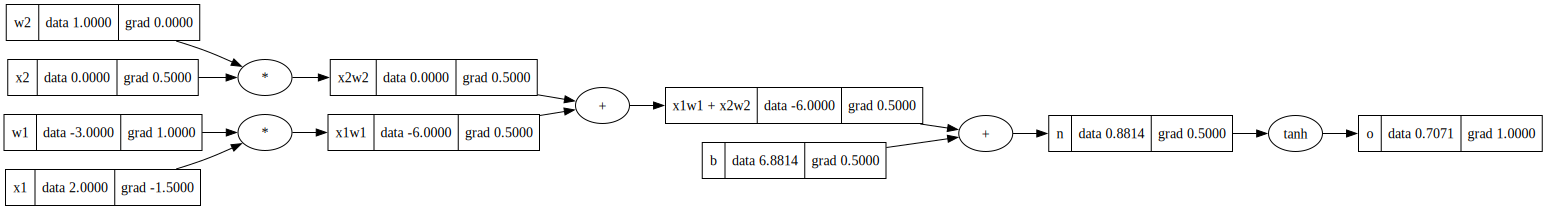

In [106]:
o.backward()
draw_dot(o)

### Topological Sort

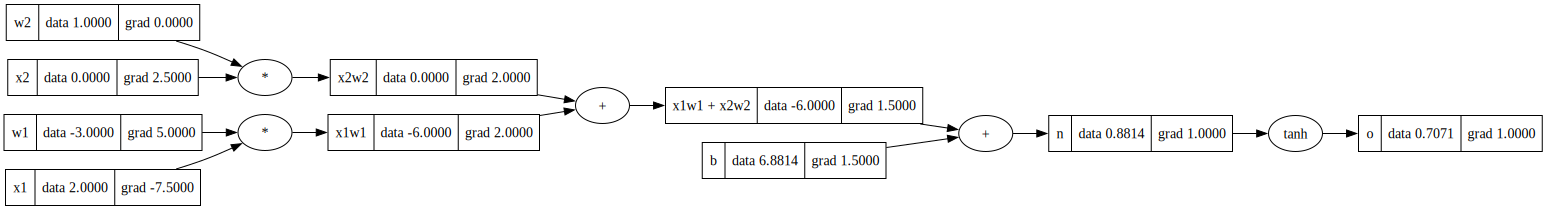

In [107]:
# https://python.plainenglish.io/topological-sort-python-119f2c012b52
# Edges from left to right
o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

for node in reversed(topo):
    node._backward()

draw_dot(o)

### Automatic backprop for neuron via backward

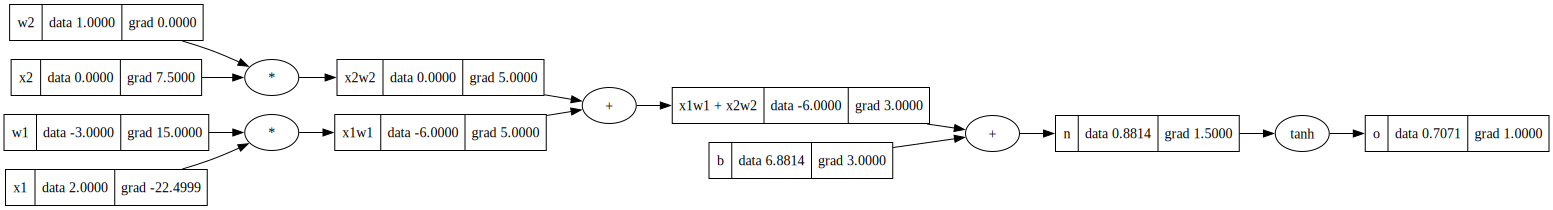

In [108]:
o.grad = 1.0
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x2w2._backward()
x1w1._backward()
draw_dot(o)

## Manual backprop for neuron

Work right to left: o -> n -> x1w1x2w2 -> (x1w1, x2w2) -> (x1, w1, x2, w2)

```
# do/dn = 1 - tanh(n)^2 = 1 - o^2
# + nodes route gradient unchanged
# * nodes: grad of each input = other_input * upstream_grad
```

1 - o^2 = 0.5000,  n.grad = 0.5000


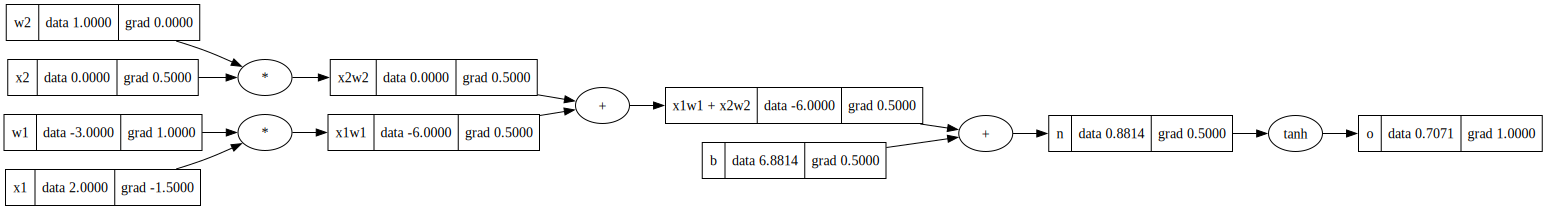

In [109]:
# Backprop right to left

# Output
o.grad = 1.0

# o = tanh(n)  =>  do/dn = 1 - o^2
n.grad = (1 - o.data**2) * o.grad
print(f'1 - o^2 = {1 - o.data**2:.4f},  n.grad = {n.grad:.4f}')

# n = x1w1x2w2 + b  =>  + routes gradient
x1w1x2w2.grad = n.grad
b.grad = n.grad

# x1w1x2w2 = x1w1 + x2w2  =>  + routes gradient
x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad

# x1w1 = x1 * w1  =>  grad of each = other * upstream
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

# x2w2 = x2 * w2  =>  grad of each = other * upstream
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

draw_dot(o)

### Bug analysis for backward propagation

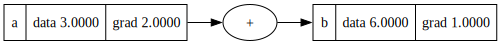

In [110]:
# Sample code
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward() # derivative of b respect to a should be 2, we are overriding the gradient
draw_dot(b)

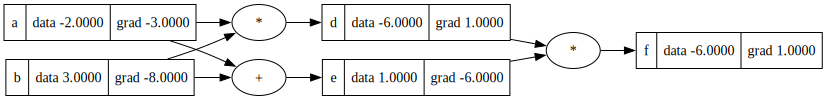

In [111]:
# Here we face this issue if we use a variable more than once!
# We overrride the gradients
# The fix for the chainrule is that we accumulate the gradients in the Value class
a = Value(-2.0, label='a')
b = Value(3.0, label='b')

d = a * b; d.label='d'
e = a + b; e.label='e'
f = d * e; f.label='f'

f.backward()

draw_dot(f)

### What we cant do with the old value class (without line with comment above)

In [141]:
a = Value(2.0)
b = Value(4.0)

a + 1 # adding a constant, which is not a ValueObject
a * 2 # = a.__mul__(2)
2 * a # = 2.__mul__(a) TypeError: unsupported operand type(s) for *: 'int' and 'Value'

a.exp()

a / b # TypeError: unsupported operand type(s) for /: 'Value' and 'Value'

a - b #TypeError: unsupported operand type(s) for -: 'Value' and 'Value'
b - a

# Division can be written as
#a * (1/b)
#a * (b**-1)


# This throws an AttributeError

#AttributeError                            Traceback (most recent call last)
#Cell In[112], line 2
#      1 a = Value(2.0)
#----> 2 a + 1 # adding a constant
#
#Cell In[97], line 15, in Value.__add__(self, other)
#     14 def __add__(self, other):
#---> 15     out = Value(self.data + other.data, (self, other), '+')
#     16     def _backward():
#     17         #self.grad = 1.0 * out.grad # chainrule, but with bug "no accumulation"
#     18         self.grad += 1.0 * out.grad # accumulate the gradients
#
#AttributeError: 'int' object has no attribute 'data'


Value(data=2.0)

### Neuron computation graph: o = tanh(x1w1 + x2w2 + b) + o.backward() as well as breakup of tanh -> more forward and backward passes

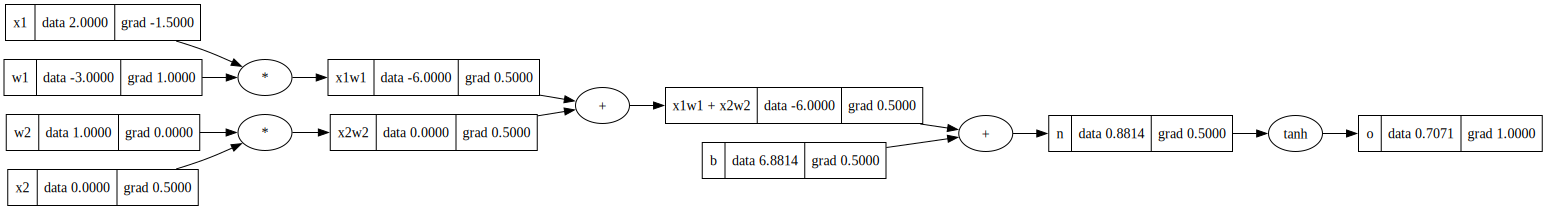

In [142]:
# https://cs231n.github.io/neural-networks-1/

# Inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# Weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# Bias
b = Value(6.881375870195432, label='b')

# Forward pass
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

o.backward()

draw_dot(o)

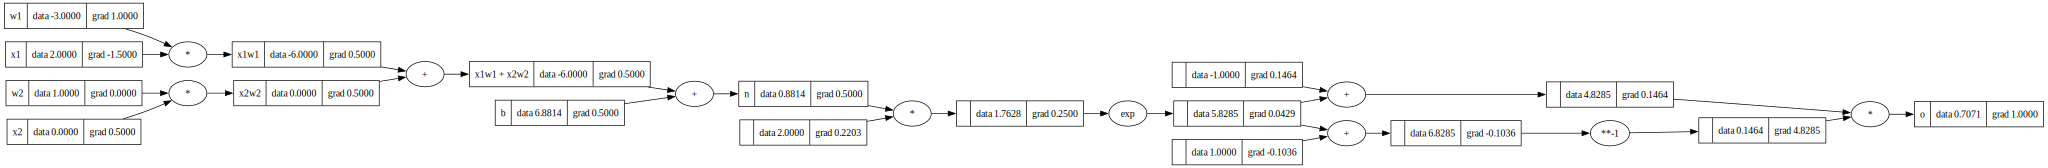

In [144]:
# https://cs231n.github.io/neural-networks-1/

# Inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# Weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# Bias
b = Value(6.881375870195432, label='b')

# Forward pass
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
#o = n.tanh(); o.label = 'o'
# ---
# We broken up tanh we expect more nodes, but forward and backward pass as well as gradients as before
e = (2*n).exp()
o = (e-1) / (e+1)
# ---
o.label = 'o'
o.backward()

draw_dot(o)

### Modern approach using pytorch

In [152]:
import torch

# define value objects - micrograd only has scalarvalues but pytorch everything is based
# around tensors which are n-dimensional arrays of scalars
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True

b = torch.Tensor([6.881375870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item()) # return single element, stripping out the tensor 
o.backward()

print('------')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071078824962277
------
x2 0.499998442511701
w2 0.0
x1 -1.499995327535103
w1 0.999996885023402


In [155]:
o # Tensor with single element and all infos
o.item() # Just gives us the value

0.7071078824962277

In [151]:
import torch

# example real live tensor
torch.tensor([[1, 2, 3], [4, 5, 6]])

torch.tensor([2.0]) # by default float32
torch.tensor([2.0]).double().dtype # casting it to float64

torch.float64

### Building a neural net

In [267]:
# Single neuron which subscribes to pytorch API
import torch

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x): # for this: x = [2.0, 3.0]; n = Neuron(2); n(x)
        # w * x + b
        #print(list(zip(self.w, x))) # takes two iterators, creates new iterator and iterates over the tuples of their corresponding entries
        #return 0.0
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

# https://blog.liang2.tw/2015Talk-DeepLearn-CNN/?full#24
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    
        
#x = [2.0, 3.0]
#n = Neuron(2)
#n = Layer(2, 3)
#n(x)
        

In [294]:
# Implement MLP from Picture -> https://blog.liang2.tw/2015Talk-DeepLearn-CNN/?full#24
x = [2.0, 3.0, -1.0] # 3D input
n = MLP(3, [4, 4, 1]) # 3 Input neurons, 2 Layers of 4 and 1 Output unit
n(x)

Value(data=-0.20242121483806091)

In [295]:
n.parameters()
len(n.parameters())

41

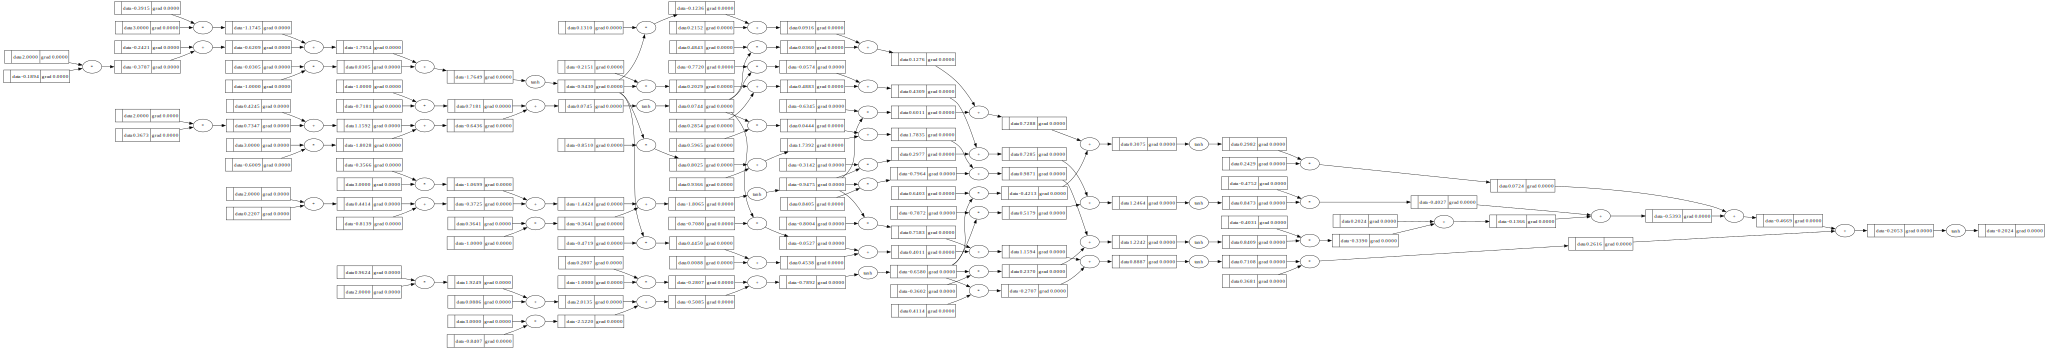

In [296]:
draw_dot(n(x))

### Simple Example dataset

In [363]:
# binary classifier neural net
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] # desired targets

# Neural nets are mathematical expression that take inputs as data


In [364]:
# tune the weights to bette predict the desirred targets, # currently high, we want to minimize
[(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]
# the more off we are the greater the loss will be

[Value(data=0.0005226123157463403),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=1.5220005268748753e-05)]

In [382]:
for k in range(20):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    # Backward pass
    for p in n.parameters():
        p.grad = 0.0 # make zero grad
    loss.backward()
    #update
    for p in n.parameters():
        p.data += -0.05 * p.grad # Vector pointingng into direction of loss (somewhere between 0.01 and 0.1)

    print(k, loss.data)

0 0.00017028445834973063
1 0.00016942345554391672
2 0.0001685706742275044
3 0.00016772599911802068
4 0.00016688931706168984
5 0.00016606051698475553
6 0.0001652394898461007
7 0.0001644261285911669
8 0.00016362032810712595
9 0.0001628219851792559
10 0.00016203099844846664
11 0.00016124726836996698
12 0.00016047069717304915
13 0.00015970118882189423
14 0.00015893864897744583
15 0.00015818298496027126
16 0.0001574341057143765
17 0.00015669192177198115
18 0.0001559563452191875
19 0.00015522728966255563


In [383]:
#ypred = [n(x) for x in xs]
#loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
#loss

In [384]:
#n.layers[0].neurons[0].w[0].grad

In [385]:
#n.layers[0].neurons[0].w[0].data # increase this will minimize the loss

In [386]:
#for p in n.parameters():
#    p.data += -0.1 * p.grad # Vector pointingng into direction of loss

In [387]:
ypred

[Value(data=0.9876620700644893),
 Value(data=-1.0),
 Value(data=-1.0),
 Value(data=0.9982671484284615)]

In [356]:
n.parameters()

[Value(data=2.6992979682515448),
 Value(data=-4.059729165039173),
 Value(data=-1.7692533856220993),
 Value(data=-1.3268551666607034),
 Value(data=-1.629884889130894),
 Value(data=-4.41781757285979),
 Value(data=1.095349280156839),
 Value(data=-0.79891641522975),
 Value(data=2.5749675010375155),
 Value(data=-15.534513709575952),
 Value(data=16.86159040527162),
 Value(data=0.6584338971000263),
 Value(data=13.298871794674028),
 Value(data=12.874641198923465),
 Value(data=-18.361215956384807),
 Value(data=3.445946034993506),
 Value(data=0.42959198953631766),
 Value(data=-4.29272896795888),
 Value(data=3.596562917396857),
 Value(data=-1.1152575513743508),
 Value(data=0.5774431063298083),
 Value(data=2.0847194310373114),
 Value(data=-4.301974071687519),
 Value(data=4.96523339007194),
 Value(data=2.6443764221809594),
 Value(data=-1.4496090177396979),
 Value(data=-0.48166259422433355),
 Value(data=2.314401577103675),
 Value(data=-3.8946983400950455),
 Value(data=-1.9218142332662396),
 Value(da